# 07. 制御系と回路 — 伝達関数とフィードバック

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 10. Exercises / 11. Advanced Notes |

> RC/RLC の過渡応答とフィードバックの閉ループを通して、04〜06 章を実際のシステムに接続する。

In [1]:
# Shared setup: make laplace_book importable, fix seeds, inline + plotly rendering.
%matplotlib inline
import sys
from pathlib import Path

try:
    import laplace_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "laplace_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from IPython.display import display

from laplace_book import transforms, systems, circuits, plotting, datasets, widgets
from laplace_book.transforms import t, s, L, Linv, numeric_laplace, partial_fractions

import plotly.io as pio
pio.renderers.default = "notebook_connected"

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)
sp.init_printing()

## 1. Big Picture / 2. Problem

回路や制御系は「入力 → 出力」を持つ **システム**。$s$ 領域でインピーダンス($R,\ sL,\ 1/sC$)を書くと、
分圧の規則がそのまま伝達関数になります。本章は RC/RLC とフィードバックを通して 04〜06 章を実機に接続します。

## 3. RC 回路 — 1次系のステップ応答

低域通過 RC: $H(s)=\dfrac{1}{RCs+1}$、時定数 $\tau=RC$。ステップ応答は $1-e^{-t/\tau}$ で、
$t=\tau$ で約 63% に到達します。

DC gain: 1.0  time constant: 0.001


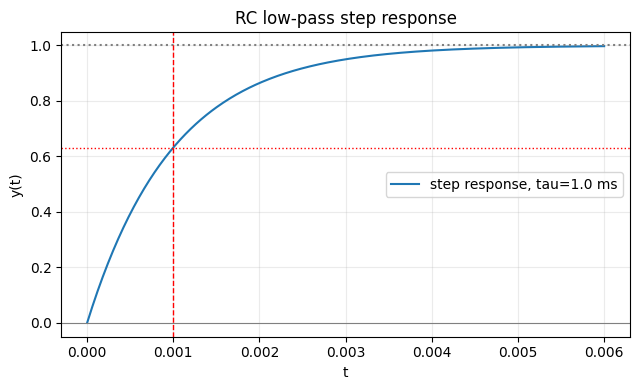

In [2]:
R, C = 1000.0, 1e-6           # tau = RC = 1 ms
sys = circuits.rc_lowpass(R, C)
tau = R * C
tt = np.linspace(0, 6 * tau, 400)
y = systems.step_response(sys, tt)
ax = plotting.plot_time_responses(tt, [y], labels=[f"step response, tau={tau*1e3:.1f} ms"],
                                  title="RC low-pass step response")
ax.axhline(1.0, color="gray", ls=":"); ax.axvline(tau, color="r", ls="--", lw=1)
ax.axhline(1 - np.exp(-1), color="r", ls=":", lw=1)   # ~63% at t = tau
plt.tight_layout()
print("DC gain:", systems.dc_gain(sys), " time constant:", systems.time_constant(sys))

## 4. RLC 回路 — 2次系の過渡

直列 RLC(コンデンサ出力): $H(s)=\dfrac{1}{LCs^2+RCs+1}$。$\omega_n=1/\sqrt{LC}$、$\zeta=\tfrac{R}{2}\sqrt{C/L}$。
$R$ を変えると underdamped / critical / overdamped が切り替わります。

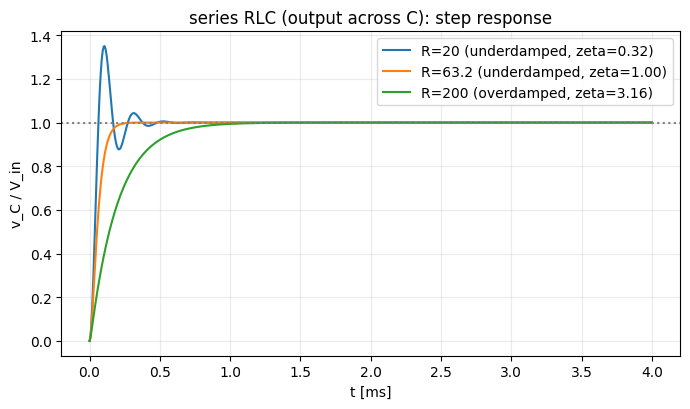

In [3]:
L, C = 1e-3, 1e-6
tt = np.linspace(0, 4e-3, 600)
fig, ax = plt.subplots(figsize=(7, 4.2))
for R in [20.0, 63.2, 200.0]:
    sys = circuits.rlc_series_vc(R, L, C)
    p = circuits.rlc_params(R, L, C)
    ax.plot(tt * 1e3, systems.step_response(sys, tt), label=f"R={R:g} ({p['regime']}, zeta={p['zeta']:.2f})")
ax.axhline(1.0, color="gray", ls=":")
ax.set_title("series RLC (output across C): step response")
ax.set_xlabel("t [ms]"); ax.set_ylabel("v_C / V_in"); ax.legend(); ax.grid(alpha=0.25)
plt.tight_layout()

## 5. フィードバック — 閉ループ伝達関数

負帰還の閉ループは

$$ H_{\mathrm{closed}}(s)=\frac{G(s)}{1+G(s)K(s)}. $$

フィードバックは **極を動かし**、応答の速さと安定性を変えます。下のスライダーでループゲイン $K$ を上げ、
閉ループ極が左へ動いて応答が速くなる一方、上げすぎると振動的になる様子を見ます。

In [4]:
# Interactive: loop gain K reshapes the closed-loop poles and step response.
widgets.explore_feedback()

interactive(children=(FloatSlider(value=1.0, description='K', max=8.0, min=0.1), Output()), _dom_classes=('wid…

<function laplace_book.widgets.explore_feedback.<locals>._draw(K=1.0)>

## 5b. 根軌跡 — ゲインで閉ループ極が描く軌跡

ループゲイン $k$ を $0\to\infty$ と動かすと、閉ループ極(特性方程式 $D_G(s)+k\,N_G(s)=0$ の根)が
$s$ 平面に **軌跡** を描く。$k=0$ で開ループ極(×)から出発し、増やすと開ループ零点(○)や無限遠へ向かう。
古典例 $G(s)=1/(s(s+1))$ では2極が $-0.5$ で合流し、虚軸と平行に上下へ抜ける。

3-pole plant: closed loop becomes unstable around k = 65  (Routh bound: k < 60)


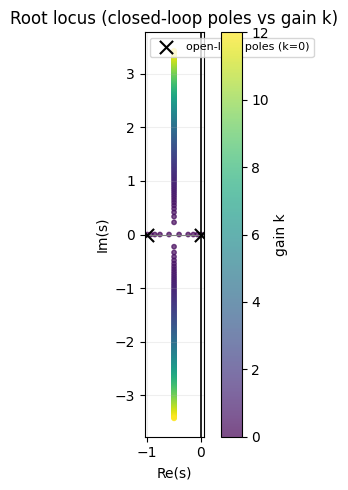

In [5]:
G = systems.tf([1.0], [1.0, 1.0, 0.0])      # 1 / (s(s+1))
plotting.plot_root_locus(G, np.linspace(0, 12, 200))
plt.tight_layout()

# A 3-pole plant loses stability past a finite gain (a branch crosses into the RHP).
G3 = systems.tf([1.0], np.poly([-1.0, -2.0, -3.0]))   # 1/((s+1)(s+2)(s+3))
ks = np.arange(0, 120, 5)
_, loc3 = systems.root_locus(G3, ks)
max_re = np.array([r.real.max() for r in loc3])
kcross = ks[np.argmax(max_re > 0)]
print(f"3-pole plant: closed loop becomes unstable around k = {kcross}  (Routh bound: k < 60)")

## 6. Bode 線図の入口

周波数応答 $H(i\omega)$ の大きさ・位相を対数で描くのが Bode 線図。RC 低域通過のロールオフを見ます。

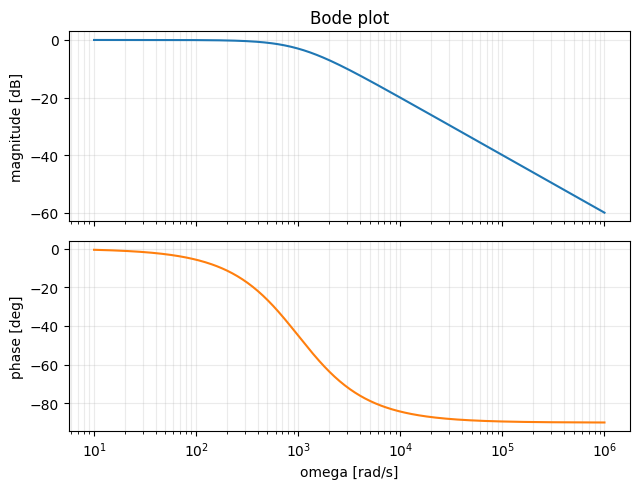

In [6]:
sys = circuits.rc_lowpass(1000.0, 1e-6)
w = np.logspace(1, 6, 400)
plotting.plot_bode(sys, w=w)
plt.tight_layout()

## 7〜11. Application / Exercises / Advanced & TODO

- **応用**: アンチエイリアスフィルタ、サスペンション、サーボ位置決め、温度制御。
- **演習(Basic)**: RC で時定数を半分にするには $R,C$ をどうする?
- **演習(Applied)**: `systems.feedback` で $G=1/(s(s+1))$ の閉ループ極を $K$ について追え。
- **Advanced**: 比例 + 積分(PI)制御 $K(s)=K_p+K_i/s$ が定常偏差を消す理由を最終値定理で示せ。

> **TODO(今後の拡張)**: PID 制御の設計例、位相余裕・ゲイン余裕、
> オペアンプ回路の伝達関数、ナイキスト線図を追加(根軌跡は §5b で実装済み)。